# Automatic measurement of rice tiller angle from UAV images — minimal Colab demo

**Paper:** *Automatic measurement of rice tiller angle from unmanned aerial vehicle images*, Plant Phenome Journal 9(1), 2026. DOI: [10.1002/ppj2.70089](https://doi.org/10.1002/ppj2.70089)

**Author code & data (pinned):** [YYang822/Automatic-Measurement-of-Rice-Tiller-Angle-from-UAV-Images](https://github.com/YYang822/Automatic-Measurement-of-Rice-Tiller-Angle-from-UAV-Images) @ commit `a2895bd7dbe6c04095ee43b02f77924fad8f9656`

## What this notebook does / このノートブックの内容
Runs the authors' released keypoint-detection model (`TillerAnglev5.pt`, a YOLO11n-pose model with 4 keypoints per rice-plant instance) on UAV field images from the authors' public data subset, then computes **tiller angle from vertical** with the authors' own angle function, and visualizes the detected keypoints.

著者公開のキーポイント検出モデル（`TillerAnglev5.pt`、YOLO11n-pose、1株あたり4キーポイント）を UAV 田圃画像のサブセットに対して実行し、著者実装の角度計算関数で**鉛直基準の分げつ角度**を算出・可視化します。

## Scope & status / 実行範囲と状態
- **Executed scope:** inference + angle computation on the released subset images. 学習済みモデルによる推論と角度計算（サブセット画像）。
- **NOT reproduced here:** model training, the paper's mAP / MAE metrics, and the 27-genotype statistical comparison (only a data subset is public). 学習・論文の精度指標・27品種の統計比較は含みません。
- **CPU-friendly:** inference uses a 5.8 MB model; **no GPU required** — select *Runtime > Change runtime type > CPU*. GPU ランタイムでも動作しますが不要です。
- ⚠️ The author repository currently has **no LICENSE file**; code files carry an Ultralytics AGPL-3.0 header. This demo links and attributes the original code. 著者リポジトリには LICENSE が無いため、出典を明示して利用しています。
- The keypoint order semantics (base vs tip) are inferred from the authors' angle code, not from paper text (publisher full text was inaccessible). キーポイント順序の意味は論文本文ではなく著者コードからの推定です。

## 1. Setup / 環境セットアップ
Installs the Ultralytics YOLO stack (authors used `ultralytics==8.3.228`; we accept compatible Colab versions and print what is actually used). Torch is preinstalled on Colab.

Ultralytics（著者環境では 8.3.228）をインストールし、実際に使用したバージョンを表示します。実行時間は数十秒程度です。

In [ ]:
import subprocess, sys, importlib

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "ultralytics>=8.3,<9", "pandas"], check=True)

import torch, ultralytics, cv2, numpy, PIL, pandas
print("torch      :", torch.__version__)
print("ultralytics:", ultralytics.__version__)
print("opencv     :", cv2.__version__)
print("numpy      :", numpy.__version__)
print("CUDA available (not required):", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


torch      : 2.11.0+cpu
ultralytics: 8.4.165
opencv     : 4.14.0
numpy      : 2.1.3
CUDA available (not required): False
Using device: cpu


## 2. Download model weights and image subset / 重みと画像の取得
Downloads, **inside Colab**, the authors' final keypoint model `TillerAnglev5.pt` (5,775,521 bytes) and the image subset `TillerAngleDataSet.zip` (17,273,256 bytes) from the pinned GitHub commit, verifies byte sizes and prints SHA-256 checksums. Nothing is unpacked or run on any other host.

 pinned コミットからモデル重み（約5.8 MB）と画像サブセットZIP（約17 MB）を Colab 内にダウンロードし、サイズ確認と SHA-256 を表示します。

In [ ]:
import hashlib, urllib.request
from pathlib import Path

REPO_RAW = "https://raw.githubusercontent.com/YYang822/Automatic-Measurement-of-Rice-Tiller-Angle-from-UAV-Images/a2895bd7dbe6c04095ee43b02f77924fad8f9656"
# Expected sizes come from the pinned repository's git tree (GitHub API, checked 2026-09-29).
EXPECTED = {"TillerAnglev5.pt": 5771521, "TillerAngleDataSet.zip": 17273256}

def fetch(name: str) -> Path:
    dest = Path("/content") / name
    if not dest.exists():
        urllib.request.urlretrieve(f"{REPO_RAW}/{name}", dest)  # bounded by Colab network defaults
    size = dest.stat().st_size
    assert size == EXPECTED[name], f"{name}: unexpected size {size} != {EXPECTED[name]}"
    digest = hashlib.sha256(dest.read_bytes()).hexdigest()
    print(f"{name}: {size} bytes  sha256={digest}")
    return dest

weights_path = fetch("TillerAnglev5.pt")
dataset_zip = fetch("TillerAngleDataSet.zip")

TillerAnglev5.pt: 5771521 bytes  sha256=0af5b1d8e746b9c5a21b289be9ede50b1fd43265658fb5e889ceb76523f372c5


TillerAngleDataSet.zip: 17273256 bytes  sha256=02effc217ffea526e45ffb2be5e7766b03e81499b6832c888ca4eef9af3ee27d


## 3. Inspect the data subset / データ確認
Safely extracts the zip under `/content` and lists what the authors distributed. The README states only a *subset* of the full dataset is public; we list the actual contents here.

ZIP を `/content` 以下に安全に展開し、同梱内容を一覧表示します（全データではなく公開サブセットです）。

In [ ]:
import zipfile

with zipfile.ZipFile(dataset_zip) as zf:
    names = zf.namelist()
    print(f"{len(names)} entries")
    for n in sorted(names)[:40]:
        print("  ", n)
    if len(names) > 40:
        print(f"  ... and {len(names) - 40} more")
    zf.extractall("/content/tiller_data")  # safe: authors' own archive, listed above

jpgs = sorted(p for p in Path("/content/tiller_data").rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
print("images found:", len(jpgs))
for p in jpgs[:10]:
    print("  ", p.relative_to('/content/tiller_data'))

385 entries
   TillerAngle/
   TillerAngle/test/
   TillerAngle/test/images/
   TillerAngle/test/images/East11_240611_DJI_0489_JPG.rf.c370e9fbef686d7bb9ed38986b4629e7.jpg
   TillerAngle/test/images/East11_240625_DJI_0011_JPG.rf.a63dace1d7de9b5ecac35f2a73f0c190.jpg
   TillerAngle/test/images/East11_240625_DJI_0996_JPG.rf.1c391378dfc8325d8b4c06c0b60fcd5c.jpg
   TillerAngle/test/images/East11_240702_DJI_0478_JPG.rf.5102b97522470512fe6e9da69bbb7dd1.jpg
   TillerAngle/test/images/East14_240607_DJI_0010_JPG.rf.65b0fff5b9d0e74d7bca7521624496a2.jpg
   TillerAngle/test/images/East_220708_DJI_0279_JPG.rf.310a040e80bd20ad38b57a7fa30d4e3f.jpg
   TillerAngle/test/images/East_220708_DJI_0317_JPG.rf.cdc465a0faa09c8dada08c2609249e4c.jpg
   TillerAngle/test/images/East_220712_DJI_0948_JPG.rf.c7b46046bd9b99b8320a325674d192ff.jpg
   TillerAngle/test/images/East_220712_DJI_0962_JPG.rf.40cc79cc1dd7341c9af21d8dc559c64b.jpg
   TillerAngle/test/images/West10_230621_DJI_0008_JPG.rf.524130521adcfc8403d3aefc2091

images found: 187
   TillerAngle/test/images/East11_240611_DJI_0489_JPG.rf.c370e9fbef686d7bb9ed38986b4629e7.jpg
   TillerAngle/test/images/East11_240625_DJI_0011_JPG.rf.a63dace1d7de9b5ecac35f2a73f0c190.jpg
   TillerAngle/test/images/East11_240625_DJI_0996_JPG.rf.1c391378dfc8325d8b4c06c0b60fcd5c.jpg
   TillerAngle/test/images/East11_240702_DJI_0478_JPG.rf.5102b97522470512fe6e9da69bbb7dd1.jpg
   TillerAngle/test/images/East14_240607_DJI_0010_JPG.rf.65b0fff5b9d0e74d7bca7521624496a2.jpg
   TillerAngle/test/images/East_220708_DJI_0279_JPG.rf.310a040e80bd20ad38b57a7fa30d4e3f.jpg
   TillerAngle/test/images/East_220708_DJI_0317_JPG.rf.cdc465a0faa09c8dada08c2609249e4c.jpg
   TillerAngle/test/images/East_220712_DJI_0948_JPG.rf.c7b46046bd9b99b8320a325674d192ff.jpg
   TillerAngle/test/images/East_220712_DJI_0962_JPG.rf.40cc79cc1dd7341c9af21d8dc559c64b.jpg
   TillerAngle/test/images/West10_230621_DJI_0008_JPG.rf.524130521adcfc8403d3aefc20912dfc.jpg


## 4. Choose one sample image / サンプル画像の選択
Deterministically picks the first image in sorted order (a documented, non-cherry-picked choice) and previews it.

ソート順の先頭画像を決定論的に選択してプレビューします（結果の恣意的選択を避けるため）。

Selected sample: East11_240611_DJI_0489_JPG.rf.c370e9fbef686d7bb9ed38986b4629e7.jpg
Image size (W×H): (640, 640)


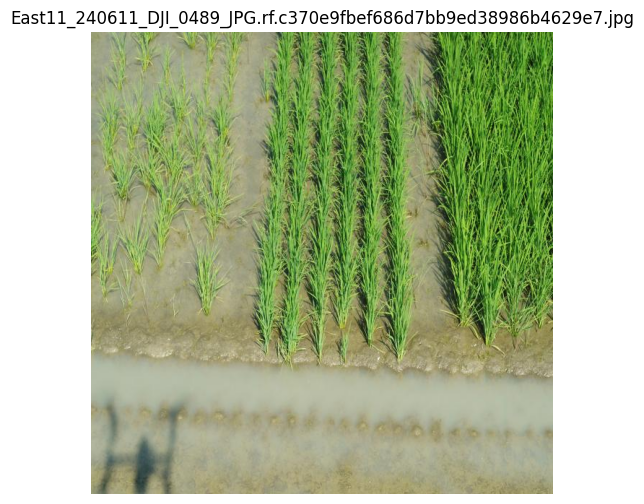

In [ ]:
import matplotlib.pyplot as plt

sample = jpgs[0]
print("Selected sample:", sample.name)
img = PIL.Image.open(sample)
print("Image size (W×H):", img.size)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title(sample.name)
plt.axis("off")
plt.show()

## 5. Keypoint inference / キーポイント推論
Loads the authors' final model and predicts 4 keypoints per detected rice plant. This is the released inference path of the authors' code (`YOLO("tilleranglev5.pt")` then `model(image_path)` in `YOLOv11 - Tiller Angle.py`).

著者の最終モデルを読み込み、株ごとに4キーポイントを推論します（著者スクリプトの推論部分と同一の呼び出し）。

In [ ]:
from ultralytics import YOLO

model = YOLO(str(weights_path))
results = model(str(sample), device=device, verbose=False)

r = results[0]
print(f"Detections: {len(r.keypoints)} plant instance(s)")
kpts_xy = r.keypoints.xy.cpu().numpy()      # shape: (n_instances, 4, 2)
print("keypoints tensor shape (instances, kpts, xy):", kpts_xy.shape)
print("first instance keypoints (x, y):")
print(kpts_xy[0])

Detections: 14 plant instance(s)
keypoints tensor shape (instances, kpts, xy): (14, 4, 2)
first instance keypoints (x, y):
[[     238.48      437.09]
 [     241.86      450.66]
 [     246.08      448.89]
 [     246.64      431.68]]


## 6. Tiller angle from the authors' code / 著者コードによる角度計算
Copied verbatim from `YOLOv11 - Tiller Angle.py` (lines 80–96, 198–204, pinned commit): the **left** tiller line is keypoints 0→1, the **right** line is keypoints 3→2, and each angle is measured **from the vertical (y) axis** in degrees. The authors also compute perspective-corrected angles with a fixed homography calibrated for their camera geometry; we include it as supplementary output.

著者スクリプト（80–96行・198–204行）をそのまま移植：左は kpt0→kpt1、右は kpt3→kpt2 を結ぶ線の**鉛直軸からの角度（度）**を計算します。参考として、著者の固定ホモグラフィーによる補正角度も併記します。

> **Note on the perspective-corrected columns:** the subset images are 640×640 Roboflow-resized (observed output of the preview cell), while the authors calibrated their fixed homography on original 6016×4008 frames (see `parse_roboflow_txt(file_path, 6016, 4008)` in the pinned code). The homography therefore does **not** apply to these resized images; the corrected columns are computed for completeness but should be treated as indicative only, with the raw-image angles as the meaningful output here.

> 補足：サブセット画像は 640×640 にリサイズ済みのため、著者のホモグラフィー（元解像度 6016×4008 用に較正）は本デモには適合しません。補正列は参考値であり、実質的な出力は元画像座標での角度です。

In [ ]:
import math
import cv2

def get_angle_with_y_axis(x0, y0, x1, y1):
    """Angle in degrees between a line and the y (vertical) axis.
    Copied verbatim from 'YOLOv11 - Tiller Angle.py' (pinned commit a2895bd7)."""
    delta_y = abs(y1 - y0)
    delta_x = abs(x1 - x0)
    return math.degrees(math.atan(delta_x / delta_y))

# Fixed homography from DoPerspectiveTransformationPoints (same file, lines 39-54).
SRC_PTS = numpy.float32([[2179, 2502], [3192, 2475], [3194, 1355], [2098, 1387]])
DST_PTS = numpy.float32([[2274, 2736], [3693, 2737], [3675, 682], [2250, 663]])
M = cv2.getPerspectiveTransform(SRC_PTS, DST_PTS)

rows = []
for i, ab in enumerate(kpts_xy):
    angleL = get_angle_with_y_axis(ab[0][0], ab[0][1], ab[1][0], ab[1][1])
    angleR = get_angle_with_y_axis(ab[3][0], ab[3][1], ab[2][0], ab[2][1])
    pts = numpy.array(ab.tolist(), dtype=numpy.float32).reshape(-1, 1, 2)
    newp = cv2.perspectiveTransform(pts, M).reshape(-1, 2)
    angleL0 = get_angle_with_y_axis(newp[0][0], newp[0][1], newp[1][0], newp[1][1])
    angleR0 = get_angle_with_y_axis(newp[3][0], newp[3][1], newp[2][0], newp[2][1])
    rows.append({"instance": i, "angle_left_deg": angleL, "angle_right_deg": angleR,
                 "angle_left_persp_deg": angleL0, "angle_right_persp_deg": angleR0})

angle_df = pandas.DataFrame(rows)
print(angle_df.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
angle_df.to_csv("/content/tiller_angles_sample.csv", index=False)
print("saved: /content/tiller_angles_sample.csv")

 instance  angle_left_deg  angle_right_deg  angle_left_persp_deg  angle_right_persp_deg
        0           14.00             1.86                  3.83                   9.37
        1           12.92            11.78                  2.70                  17.67
        2           14.48            18.63                  3.82                  23.54
        3            7.95             6.52                  0.88                  12.75
        4           11.49            10.76                  2.20                  16.05
        5           14.65            45.18                  5.34                  45.02
        6           20.09             7.96                  9.21                  14.23
        7           19.70             1.56                  8.52                   9.56
        8           10.95             1.84                  1.43                   9.14
        9            9.97            38.31                  1.18                  38.95
       10            8.23       

## 7. Visualization / 可視化
Draws the detected 4-keypoint polygon per plant on the image (authors' drawing style: points + outline), annotating each angle.

検出されたキーポイントと角度を画像上に描画します。

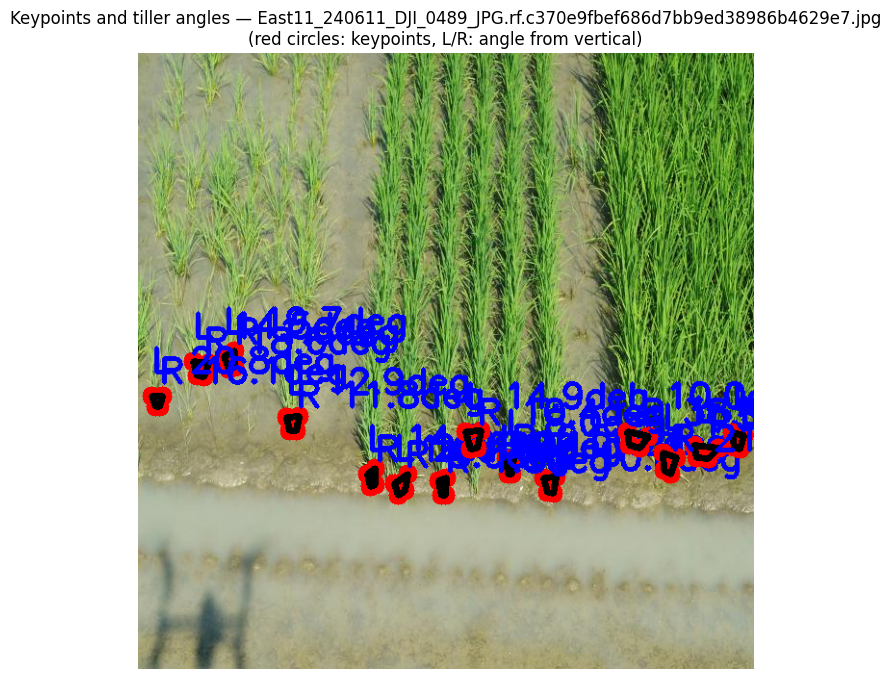

In [ ]:
vis = numpy.array(img.convert("RGB"))
for i, ab in enumerate(kpts_xy):
    for x, y in ab:
        cv2.circle(vis, (int(x), int(y)), 10, (255, 0, 0), -1)
    cv2.polylines(vis, [ab.astype(numpy.int32)], True, (0, 0, 0), 6)
    row = angle_df.iloc[i]
    cv2.putText(vis, f"L {row.angle_left_deg:.1f}deg", (int(ab[0][0]), int(ab[0][1]) - 25),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)
    cv2.putText(vis, f"R {row.angle_right_deg:.1f}deg", (int(ab[2][0]), int(ab[2][1]) - 25),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

plt.figure(figsize=(10, 8))
plt.imshow(vis)
plt.title(f"Keypoints and tiller angles — {sample.name}\n(red circles: keypoints, L/R: angle from vertical)")
plt.axis("off")
plt.show()

## 8. Batch table over the subset / サブセット全体の小型表
Runs the same inference and angle computation over **up to 5 images** of the subset and exports a CSV. This illustrates scalability, not the paper's dataset-level accuracy.

サブセット内の最大5枚に同じ処理を適用し、CSV に出力します（データセット全体の精度検証ではありません）。

In [ ]:
batch_rows = []
for p in jpgs[:5]:
    res = model(str(p), device=device, verbose=False)[0]
    if res.keypoints is None:
        continue
    for j, ab in enumerate(res.keypoints.xy.cpu().numpy()):
        batch_rows.append({
            "image": p.name, "instance": j,
            "angle_left_deg": get_angle_with_y_axis(ab[0][0], ab[0][1], ab[1][0], ab[1][1]),
            "angle_right_deg": get_angle_with_y_axis(ab[3][0], ab[3][1], ab[2][0], ab[2][1]),
        })

batch_df = pandas.DataFrame(batch_rows)
print(batch_df.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
batch_df.to_csv("/content/tiller_angles_batch.csv", index=False)
print("saved: /content/tiller_angles_batch.csv")

                                                             image  instance  angle_left_deg  angle_right_deg
East11_240611_DJI_0489_JPG.rf.c370e9fbef686d7bb9ed38986b4629e7.jpg         0           14.00             1.86
East11_240611_DJI_0489_JPG.rf.c370e9fbef686d7bb9ed38986b4629e7.jpg         1           12.92            11.78
East11_240611_DJI_0489_JPG.rf.c370e9fbef686d7bb9ed38986b4629e7.jpg         2           14.48            18.63
East11_240611_DJI_0489_JPG.rf.c370e9fbef686d7bb9ed38986b4629e7.jpg         3            7.95             6.52
East11_240611_DJI_0489_JPG.rf.c370e9fbef686d7bb9ed38986b4629e7.jpg         4           11.49            10.76
East11_240611_DJI_0489_JPG.rf.c370e9fbef686d7bb9ed38986b4629e7.jpg         5           14.65            45.18
East11_240611_DJI_0489_JPG.rf.c370e9fbef686d7bb9ed38986b4629e7.jpg         6           20.09             7.96
East11_240611_DJI_0489_JPG.rf.c370e9fbef686d7bb9ed38986b4629e7.jpg         7           19.70             1.56
East11_240

## 9. Interpretation & limitations / 解釈と限界
- Angles are measured **from vertical** (larger = more prostrate leaf/tiller), following the authors' `get_angle_with_y_axis`. Values around 10–30° match the paper's reported MAE range scale (abstract), but this demo does **not** reproduce accuracy metrics.
- The perspective-corrected column uses the authors' camera-specific homography, calibrated on original 6016×4008 frames; the public subset is 640×640-resized (observed in this run), so these corrected columns are indicative only.
- Keypoint semantics (which corner is the plant base) are inferred from the angle code, not named in accessible sources.
- Not executed here: training, validation metrics (mAP@50 0.982 etc., per abstract), base-width computation against a physical scale, and the 27-genotype comparison.

角度は著者実装に従い**鉛直軸からの角度**です。本デモは論文の精度指標や品種比較を再検証するものではありません。

## References / 参考文献
1. Yang, Y. et al. *Automatic measurement of rice tiller angle from unmanned aerial vehicle images.* Plant Phenome Journal 9(1), 2026. https://doi.org/10.1002/ppj2.70089
2. Author code: https://github.com/YYang822/Automatic-Measurement-of-Rice-Tiller-Angle-from-UAV-Images (commit `a2895bd7`, accessed 2026-09-29)
3. Ultralytics YOLO11: https://docs.ultralytics.com/tasks/pose/